In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
from PIL import Image, ImageOps
import random

In [ ]:
DATASET_PATH = Path("/content/drive/MyDrive/Dataset")
TARGET_COUNT = 500

In [ ]:
def augment_image(img):
    # Random horizontal flip
    if random.random() > 0.5:
        img = ImageOps.mirror(img)

    # Random rotation
    angle = random.randint(-20, 20)
    img = img.rotate(angle)

    return img

In [ ]:
for top_dir in DATASET_PATH.iterdir():

    if not top_dir.is_dir():
        continue

    for class_dir in top_dir.iterdir():

        if not class_dir.is_dir():
            continue

        images = [f for f in class_dir.iterdir()
          if f.is_file() and f.suffix.lower() in
          [".jpg", ".jpeg", ".png", ".bmp", ".jfif", ".webp"]]

        current_count = len(images)

        print(f"{class_dir.name}: {current_count} images")

        # -------------------------------
        # If more than 500 → keep only 500
        # -------------------------------
        if current_count > TARGET_COUNT:

            remove_count = current_count - TARGET_COUNT
            images_to_remove = random.sample(images, remove_count)

            for img_path in images_to_remove:
                img_path.unlink()

            print(f"Removed {remove_count} images")

        # -------------------------------
        # If less than 500 → augment
        # -------------------------------
        elif current_count < TARGET_COUNT:

            needed = TARGET_COUNT - current_count

            for i in range(needed):

                original = random.choice(images)

                img = Image.open(original).convert("RGB")
                img = augment_image(img)

                new_name = f"aug_{i}_{original.name}"
                save_path = class_dir / new_name

                img.save(save_path)

            print(f"Added {needed} images")

        print(f"{class_dir.name} balanced to {TARGET_COUNT}\n")

print("✅ Dataset balancing completed!")

Sandalwood: 500 images
Sandalwood balanced to 500

Ashwagandha: 500 images
Ashwagandha balanced to 500

Tulsi: 500 images
Tulsi balanced to 500

Hibiscus: 500 images
Hibiscus balanced to 500

Insulin: 500 images
Insulin balanced to 500

Turmeric: 500 images
Turmeric balanced to 500

Parijata: 500 images
Parijata balanced to 500

Bhrami: 500 images
Bhrami balanced to 500

Ekka: 500 images
Ekka balanced to 500

Amruta_Balli: 500 images
Amruta_Balli balanced to 500

Money plant: 500 images
Money plant balanced to 500

✅ Dataset balancing completed!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib.cm as cm

In [ ]:
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/Dataset")

image_size = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

AUTOTUNE = tf.data.AUTOTUNE

MODEL_SAVE_PATH = "/content/drive/MyDrive/Ayurvedic_project/model.h5"

In [ ]:
def remove_background_green(img):

    r, g, b = tf.unstack(img, axis=-1)

    exg = 2.0 * g - r - b

    exg_min = tf.reduce_min(exg)
    exg_max = tf.reduce_max(exg)

    exg_norm = (exg - exg_min) / (exg_max - exg_min + 1e-5)

    mask = exg_norm > 0.4
    mask = tf.cast(mask, tf.float32)
    mask = tf.expand_dims(mask, axis=-1)

    img_fg = img * mask

    return img_fg

In [ ]:
species_dirs = []

for top_dir in DATA_DIR.iterdir():
    if top_dir.is_dir():
        for sub_dir in top_dir.iterdir():
            if sub_dir.is_dir():
                species_dirs.append(sub_dir)

class_names = sorted([d.name for d in species_dirs])
class_to_index = {name: idx for idx, name in enumerate(class_names)}

print("Species class mapping:", class_to_index)

image_paths = []
labels = []

for species_dir in species_dirs:

    class_name = species_dir.name
    class_idx = class_to_index[class_name]
    count_for_class = 0

    for img_path in species_dir.rglob("*"):

        if img_path.is_file() and img_path.suffix.lower() in [
            ".jpg", ".jpeg", ".png", ".bmp", ".jfif", ".webp"
        ]:

            image_paths.append(str(img_path))
            labels.append(class_idx)
            count_for_class += 1

    print(f"{class_name}: {count_for_class} images found")

X = np.array(image_paths)
y = np.array(labels, dtype=np.int32)

print("\nTotal images:", len(X))
print("Species Classes:", class_names)

Species class mapping: {'Amruta_Balli': 0, 'Ashwagandha': 1, 'Bhrami': 2, 'Ekka': 3, 'Hibiscus': 4, 'Insulin': 5, 'Money plant': 6, 'Parijata': 7, 'Sandalwood': 8, 'Tulsi': 9, 'Turmeric': 10}
Sandalwood: 500 images found
Ashwagandha: 500 images found
Tulsi: 500 images found
Hibiscus: 500 images found
Insulin: 500 images found
Turmeric: 500 images found
Parijata: 500 images found
Bhrami: 500 images found
Ekka: 500 images found
Amruta_Balli: 500 images found
Money plant: 500 images found

Total images: 5500
Species Classes: ['Amruta_Balli', 'Ashwagandha', 'Bhrami', 'Ekka', 'Hibiscus', 'Insulin', 'Money plant', 'Parijata', 'Sandalwood', 'Tulsi', 'Turmeric']


In [ ]:
def load_and_preprocess(path, label):

    img = tf.io.read_file(path)

    img = tf.image.decode_image(
        img,
        channels=3,
        expand_animations=False
    )

    img.set_shape((None, None, 3))

    img = tf.image.convert_image_dtype(img, tf.float32)

    img = tf.image.resize_with_pad(
        img,
        image_size[0],
        image_size[1]
    )

    img = remove_background_green(img)

    img = img * 255.0

    img = preprocess_input(img)

    return img, tf.cast(label, tf.int32)


def make_dataset(path_array, label_array, batch_size=BATCH_SIZE, shuffle=False):

    ds = tf.data.Dataset.from_tensor_slices((path_array, label_array))

    ds = ds.map(
        load_and_preprocess,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=len(path_array))

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)

    return ds

In [ ]:
def build_model():

    base_cnn = ResNet50(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_cnn.trainable = False

    model = Sequential([

        base_cnn,

        GlobalAveragePooling2D(),

        Dense(
            128,
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(0.001)
        ),

        Dropout(0.5),

        Dense(
            len(class_names),
            activation='softmax',
            dtype='float32'
        )
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training Images : {len(X_train)}")
print(f"Testing Images  : {len(X_test)}")

# Step 2: K-Fold only on training data
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_histories = []
fold_accuracies = []

best_model = None
best_accuracy = 0

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):

    print(f"\n========== Fold {fold}/5 ==========")

    train_ds = make_dataset(
        X_train[train_idx],
        y_train[train_idx],
        shuffle=True
    )

    val_ds = make_dataset(
        X_train[val_idx],
        y_train[val_idx],
        shuffle=False
    )

    model = build_model()

    callbacks = [
        EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=3,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    loss, acc = model.evaluate(val_ds, verbose=0)

    print(f"Fold {fold} Validation Accuracy : {acc:.4f}")

    fold_accuracies.append(acc)
    fold_histories.append(history.history)

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model

print("\nAverage Validation Accuracy:",
      np.mean(fold_accuracies))

# Use best model for testing
model = best_model

print("\nEvaluating on Test Dataset...")

test_ds = make_dataset(
    X_test,
    y_test,
    shuffle=False
)

loss, test_acc = model.evaluate(
    test_ds,
    verbose=0
)

print(f"\nTesting Accuracy : {test_acc:.4f}")

pred_probs = model.predict(test_ds, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

y_true_all = np.array(y_test)
y_pred_all = np.array(pred_labels)

Training Images : 4400
Testing Images  : 1100

========== Fold 1/5 ==========
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1512s 3s/step - accuracy: 0.6940 - loss: 1.1571 - val_accuracy: 0.9432 - val_loss: 0.4516 - learning_rate: 0.0010
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 130ms/step - accuracy: 0.9057 - loss: 0.5005 - val_accuracy: 0.9727 - val_loss: 0.2968 - learning_rate: 0.0010
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 58s 129ms/step - accuracy: 0.9312 - loss: 0.3857 - val_accuracy: 0.9818 - val_loss: 0.2511 - learning_rate: 0.0010
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.9511 - loss: 0.3145 - val_accuracy: 0.9761 - val_loss: 0.2302 - learning_rate: 0.0010
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 81s 126ms/step - accuracy: 0.9565 - loss: 0.2766 - val_accuracy: 0.9795 - val_loss: 0.2029 - learning_rate: 0.0010
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 130ms/step - accuracy: 0.9665 - loss: 0.2393 - val_ac

In [ ]:
cm = confusion_matrix(y_true_all, y_pred_all)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true_all,
    y_pred_all,
    target_names=class_names
))


Confusion Matrix:
[[ 87   0   2   8   1   0   0   0   0   2   0]
 [  1  98   0   1   0   0   0   0   0   0   0]
 [  0   0  99   0   0   1   0   0   0   0   0]
 [  1   0   0  99   0   0   0   0   0   0   0]
 [  0   0   0   0  99   0   0   0   0   1   0]
 [  0   0   3   0   0  96   0   0   0   0   1]
 [  0   0   0   0   0   0 100   0   0   0   0]
 [  0   0   0   0   0   0   0 100   0   0   0]
 [  0   0   0   0   0   0   0   0 100   0   0]
 [  0   0   0   0   0   0   0   0   0 100   0]
 [  0   0   0   0   0   0   0   0   0   0 100]]

Classification Report:
              precision    recall  f1-score   support

Amruta_Balli       0.98      0.87      0.92       100
 Ashwagandha       1.00      0.98      0.99       100
      Bhrami       0.95      0.99      0.97       100
        Ekka       0.92      0.99      0.95       100
    Hibiscus       0.99      0.99      0.99       100
     Insulin       0.99      0.96      0.97       100
 Money plant       1.00      1.00      1.00       100
    Pa

In [ ]:
model.save(MODEL_SAVE_PATH)
print(f"✅ Model saved to {MODEL_SAVE_PATH}")

✅ Model saved to /content/drive/MyDrive/Ayurvedic_project/model.h5


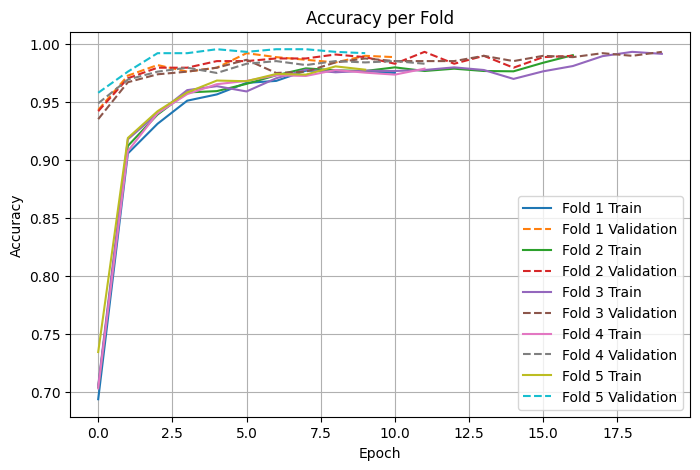

In [ ]:
plt.figure(figsize=(8,5))

for i, hist in enumerate(fold_histories):
    plt.plot(hist["accuracy"], label=f"Fold {i+1} Train")
    plt.plot(hist["val_accuracy"], "--", label=f"Fold {i+1} Validation")

plt.title("Accuracy per Fold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

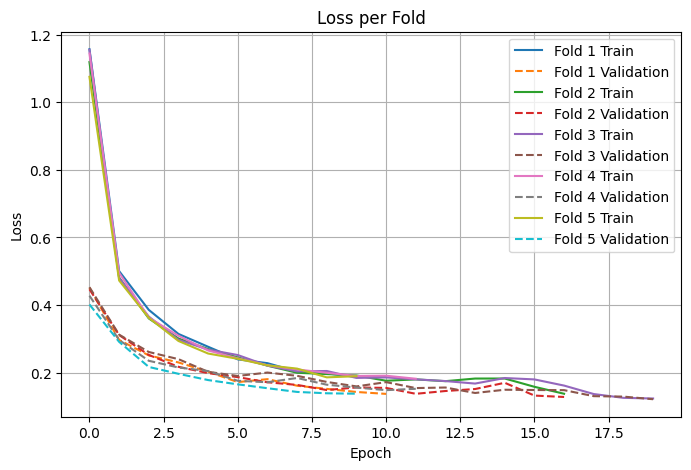

In [ ]:
plt.figure(figsize=(8,5))

for i, hist in enumerate(fold_histories):
    plt.plot(hist["loss"], label=f"Fold {i+1} Train")
    plt.plot(hist["val_loss"], "--", label=f"Fold {i+1} Validation")

plt.title("Loss per Fold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
!git config --global user.nithyakbhat

In [5]:
!git config --global user.nithyakbhat@gmail.com